# Encoder Ordering Comparison: Model2Vec vs MiniLM vs MobileCLIP2-B vs OpenCLIP-Distilled MobileCLIP2-B

Task: for each prompt, rank 80 COCO class names by cosine similarity. Compare orderings.

**Encoders evaluated:**
- **MiniLM** (`all-MiniLM-L6-v2`, 384-d) — transformer baseline.
- **Model2Vec** (`potion-base-8M`, 256-d) — static distilled embeddings.
- **MobileCLIP2-B** (raw text tower, 512-d) — TorchScript text encoder.
- **OpenCLIP-Distilled MobileCLIP2-B** (256-d) — MobileCLIP2-B text path with a 256-d linear head, distilled from OpenCLIP ViT-L/14 (`sam3_litetext_b_full_best.pt`).

**Metrics:** Recall@k vs gold (k=1,3,5,10), MRR, Spearman/Kendall correlation, top-k Jaccard, latency per encode.


In [1]:
import os, json, time, re
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau

ROOT = Path(r'd:/DVCon')
DATASET = ROOT / 'KG-Intent Resolver' / 'build' / 'dataset.jsonl'
MINILM_PATH = ROOT / 'models--sentence-transformers--all-MiniLM-L6-v2' / 'snapshots' / 'c9745ed1d9f207416be6d2e6f8de32d1f16199bf'
LOCAL_M2V = ROOT / 'image Process Pipeline' / 'potion-base-8M'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


In [2]:
COCO = ['person','bicycle','car','motorcycle','airplane','bus','train','truck','boat','traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball','kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair','couch','potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush']
assert len(COCO) == 80

## Load both encoders

In [3]:
from transformers import AutoTokenizer, AutoModel

mini_tok = AutoTokenizer.from_pretrained(str(MINILM_PATH), local_files_only=True)
mini_model = AutoModel.from_pretrained(str(MINILM_PATH), local_files_only=True).to(DEVICE).eval()

def _mean_pool(h, m):
    m = m.unsqueeze(-1).float()
    return (h * m).sum(1) / m.sum(1).clamp(min=1e-9)

@torch.no_grad()
def encode_minilm(texts):
    enc = mini_tok(list(texts), padding=True, truncation=True, return_tensors='pt').to(DEVICE)
    out = mini_model(**enc)
    v = _mean_pool(out.last_hidden_state, enc['attention_mask'])
    v = F.normalize(v, p=2, dim=-1)
    return v.cpu().numpy().astype(np.float32)

print('minilm dim:', encode_minilm(['probe']).shape)

minilm dim: (1, 384)


In [4]:
from model2vec import StaticModel
from huggingface_hub import snapshot_download

M2V_NAME = 'minishlab/potion-base-8M'
if not (LOCAL_M2V / 'config.json').exists():
    snapshot_download(repo_id=M2V_NAME, local_dir=str(LOCAL_M2V), local_dir_use_symlinks=False)
m2v = StaticModel.from_pretrained(str(LOCAL_M2V))

def encode_m2v(texts):
    v = np.asarray(m2v.encode(list(texts)), dtype=np.float32)
    n = np.linalg.norm(v, axis=-1, keepdims=True).clip(min=1e-8)
    return v / n

print('m2v dim:', encode_m2v(['probe']).shape)

m2v dim: (1, 256)


## Load MobileCLIP2-B (raw text tower) and OpenCLIP-Distilled MobileCLIP2-B (256-d)


In [5]:
import os
from transformers import CLIPTokenizer
import torch.nn as nn

SAM3_DIR = ROOT / 'SAM3-LiteText-DIY'
TS_PATH  = SAM3_DIR / 'mobileclip2_b.ts'
BEST_CKPT = SAM3_DIR / 'sam3_litetext_b_full_best.pt'

mc_ts = torch.jit.load(str(TS_PATH), map_location=DEVICE).eval()
clip_tok = CLIPTokenizer.from_pretrained('openai/clip-vit-base-patch32')

_MC_FN = None
for n in ('encode_text', 'forward_text', 'text_features', 'forward'):
    if hasattr(mc_ts, n):
        _MC_FN = getattr(mc_ts, n); break
assert _MC_FN is not None

@torch.no_grad()
def encode_mobileclip(texts):
    ids = clip_tok(list(texts), padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt').input_ids.to(DEVICE)
    out = _MC_FN(ids)
    out = out if isinstance(out, torch.Tensor) else out[0]
    if out.ndim > 2:
        out = out.mean(dim=1)
    v = F.normalize(out.float(), p=2, dim=-1)
    return v.cpu().numpy().astype(np.float32)

print('mobileclip2-b dim:', encode_mobileclip(['probe']).shape)

# OpenCLIP-Distilled MobileCLIP2-B: same backbone + 256-d head, weights from best.pt
ckpt = torch.load(str(BEST_CKPT), map_location=DEVICE, weights_only=False)
L_CTX    = ckpt.get('context_length', 16)
PROJ_DIM = ckpt.get('proj_dim', 256)
print(f'OpenCLIP-distill ckpt: L_CTX={L_CTX} proj_dim={PROJ_DIM} epoch={ckpt.get("epoch")} loss={ckpt.get("avg_loss"):.4f}')

ds_ts = torch.jit.load(str(TS_PATH), map_location=DEVICE).eval()
ds_ts.load_state_dict(ckpt['student_state'])
_DS_FN = None
for n in ('encode_text', 'forward_text', 'text_features', 'forward'):
    if hasattr(ds_ts, n):
        _DS_FN = getattr(ds_ts, n); break

# Probe student dim
with torch.no_grad():
    pid = clip_tok(['probe'], padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt').input_ids.to(DEVICE)
    po = _DS_FN(pid)
    po = po if isinstance(po, torch.Tensor) else po[0]
    if po.ndim > 2: po = po.mean(dim=1)
    student_dim = po.shape[-1]

ds_head = nn.Linear(student_dim, PROJ_DIM).to(DEVICE)
ds_head.load_state_dict(ckpt['head_state'])
ds_head.eval()

@torch.no_grad()
def encode_openclip_distill(texts):
    ids = clip_tok(list(texts), padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt').input_ids.to(DEVICE)
    if L_CTX < ids.shape[1]:
        ids = ids.clone(); ids[:, L_CTX:] = 0
    out = _DS_FN(ids)
    out = out if isinstance(out, torch.Tensor) else out[0]
    if out.ndim > 2: out = out.mean(dim=1)
    v = ds_head(out.float())
    v = F.normalize(v, p=2, dim=-1)
    return v.cpu().numpy().astype(np.float32)

print('openclip-distill dim:', encode_openclip_distill(['probe']).shape)


mobileclip2-b dim: (1, 512)
OpenCLIP-distill ckpt: L_CTX=16 proj_dim=256 epoch=81 loss=0.0374
openclip-distill dim: (1, 256)


## COCO class embeddings

In [6]:
PROMPT_TMPL = 'a photo of a {}'
coco_emb_ml = encode_minilm([PROMPT_TMPL.format(c) for c in COCO])
coco_emb_m2 = encode_m2v([PROMPT_TMPL.format(c) for c in COCO])
coco_emb_mc = encode_mobileclip([PROMPT_TMPL.format(c) for c in COCO])
coco_emb_ds = encode_openclip_distill([PROMPT_TMPL.format(c) for c in COCO])
print('minilm coco:', coco_emb_ml.shape, ' m2v coco:', coco_emb_m2.shape)
print('mobileclip coco:', coco_emb_mc.shape, ' openclip-distill coco:', coco_emb_ds.shape)


minilm coco: (80, 384)  m2v coco: (80, 256)
mobileclip coco: (80, 512)  openclip-distill coco: (80, 256)


## Load eval set from dataset.jsonl

In [7]:
records = []
with open(DATASET, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))
prompts = [r['prompt'] for r in records]
gold = [set(r['class_ids']) for r in records]
print('eval records:', len(prompts))

eval records: 503


## Compute per-prompt rankings (latency timed)

In [8]:
# MiniLM
t0 = time.perf_counter()
q_ml = encode_minilm(prompts)
sims_ml = q_ml @ coco_emb_ml.T
t_ml = time.perf_counter() - t0

# Model2Vec
t0 = time.perf_counter()
q_m2 = encode_m2v(prompts)
sims_m2 = q_m2 @ coco_emb_m2.T
t_m2 = time.perf_counter() - t0

# MobileCLIP2-B raw
_ = encode_mobileclip(prompts[:8])
if DEVICE == 'cuda': torch.cuda.synchronize()
t0 = time.perf_counter()
q_mc = encode_mobileclip(prompts)
if DEVICE == 'cuda': torch.cuda.synchronize()
sims_mc = q_mc @ coco_emb_mc.T
t_mc = time.perf_counter() - t0

# OpenCLIP-distilled MobileCLIP2-B (256-d)
_ = encode_openclip_distill(prompts[:8])
if DEVICE == 'cuda': torch.cuda.synchronize()
t0 = time.perf_counter()
q_ds = encode_openclip_distill(prompts)
if DEVICE == 'cuda': torch.cuda.synchronize()
sims_ds = q_ds @ coco_emb_ds.T
t_ds = time.perf_counter() - t0

rank_ml = np.argsort(-sims_ml, axis=1)
rank_m2 = np.argsort(-sims_m2, axis=1)
rank_mc = np.argsort(-sims_mc, axis=1)
rank_ds = np.argsort(-sims_ds, axis=1)

print(f'MiniLM            total: {t_ml:.3f}s  per-prompt: {t_ml/len(prompts)*1000:.2f}ms')
print(f'Model2Vec         total: {t_m2:.3f}s  per-prompt: {t_m2/len(prompts)*1000:.3f}ms')
print(f'MobileCLIP2-B     total: {t_mc:.3f}s  per-prompt: {t_mc/len(prompts)*1000:.2f}ms')
print(f'OpenCLIP-distill  total: {t_ds:.3f}s  per-prompt: {t_ds/len(prompts)*1000:.2f}ms')


MiniLM            total: 0.116s  per-prompt: 0.23ms
Model2Vec         total: 0.009s  per-prompt: 0.018ms
MobileCLIP2-B     total: 1.882s  per-prompt: 3.74ms
OpenCLIP-distill  total: 1.598s  per-prompt: 3.18ms


## Recall@k and MRR vs gold

In [9]:
def recall_at_k(ranks, gold, k):
    hits = 0
    for i, g in enumerate(gold):
        topk = set(ranks[i, :k].tolist())
        if topk & g:
            hits += 1
    return hits / len(gold)

def mrr(ranks, gold):
    s = 0.0
    for i, g in enumerate(gold):
        rr = 0.0
        for pos, cid in enumerate(ranks[i]):
            if int(cid) in g:
                rr = 1.0 / (pos + 1)
                break
        s += rr
    return s / len(gold)

Ks = [1, 3, 5, 10]
rows = []
for name, ranks in [('MiniLM', rank_ml), ('Model2Vec', rank_m2), ('MobileCLIP2-B', rank_mc), ('OpenCLIP-distill', rank_ds)]:
    row = [name] + [f'{recall_at_k(ranks, gold, k):.3f}' for k in Ks] + [f'{mrr(ranks, gold):.3f}']
    rows.append(row)

header = ['encoder'] + [f'R@{k}' for k in Ks] + ['MRR']
print('  '.join(f'{h:>18s}' for h in header))
for r in rows:
    print('  '.join(f'{v:>18s}' for v in r))


           encoder                 R@1                 R@3                 R@5                R@10                 MRR
            MiniLM               0.660               0.883               0.926               0.956               0.778
         Model2Vec               0.640               0.845               0.899               0.956               0.753
     MobileCLIP2-B               0.658               0.869               0.928               0.974               0.776
  OpenCLIP-distill               0.608               0.783               0.847               0.895               0.713


## Rank correlation between encoders

In [10]:
spearmans = []
kendalls = []
for i in range(len(prompts)):
    # compare full 80-class score vectors
    s, _ = spearmanr(sims_ml[i], sims_m2[i])
    k, _ = kendalltau(sims_ml[i], sims_m2[i])
    spearmans.append(s); kendalls.append(k)
spearmans = np.array(spearmans); kendalls = np.array(kendalls)

print(f'Spearman: mean={spearmans.mean():.3f}  median={np.median(spearmans):.3f}  min={spearmans.min():.3f}  max={spearmans.max():.3f}')
print(f'Kendall : mean={kendalls.mean():.3f}  median={np.median(kendalls):.3f}  min={kendalls.min():.3f}  max={kendalls.max():.3f}')

Spearman: mean=0.444  median=0.461  min=-0.043  max=0.786
Kendall : mean=0.315  median=0.325  min=-0.028  max=0.602


## Top-k Jaccard overlap between encoders

In [11]:
def jaccard_topk(rA, rB, k):
    js = []
    for i in range(len(rA)):
        a = set(rA[i, :k].tolist())
        b = set(rB[i, :k].tolist())
        u = a | b
        js.append(len(a & b) / len(u) if u else 0.0)
    return float(np.mean(js))

for k in Ks:
    print(f'top-{k} Jaccard MiniLM vs M2V: {jaccard_topk(rank_ml, rank_m2, k):.3f}')

top-1 Jaccard MiniLM vs M2V: 0.473
top-3 Jaccard MiniLM vs M2V: 0.355
top-5 Jaccard MiniLM vs M2V: 0.341
top-10 Jaccard MiniLM vs M2V: 0.344


## Disagreement examples: prompts where encoders pick different top-1 class

In [12]:
diffs = []
for i in range(len(prompts)):
    t1_ml = int(rank_ml[i, 0]); t1_m2 = int(rank_m2[i, 0])
    if t1_ml != t1_m2:
        diffs.append((i, t1_ml, t1_m2))
print(f'disagreement on top1: {len(diffs)} / {len(prompts)} ({len(diffs)/len(prompts):.1%})')

for i, a, b in diffs[:20]:
    gold_names = [COCO[c] for c in gold[i]]
    ok_ml = 'OK' if a in gold[i] else 'X '
    ok_m2 = 'OK' if b in gold[i] else 'X '
    print(f'{prompts[i]!r:60s} gold={gold_names}  ML={COCO[a]} [{ok_ml}]  M2V={COCO[b]} [{ok_m2}]')

disagreement on top1: 265 / 503 (52.7%)
'something to make rooms look nice'                          gold=['potted plant', 'vase']  ML=couch [X ]  M2V=bed [X ]
'what do you put on shelves for beauty'                      gold=['potted plant', 'vase']  ML=couch [X ]  M2V=refrigerator [X ]
'an object used to brighten indoor spaces'                   gold=['potted plant', 'vase']  ML=traffic light [X ]  M2V=bed [X ]
'the kind of thing that makes spaces welcoming'              gold=['potted plant', 'vase']  ML=toilet [X ]  M2V=couch [X ]
'something to place in your home for aesthetics'             gold=['potted plant', 'vase']  ML=couch [X ]  M2V=sink [X ]
'an object used for household maintenance tasks'             gold=['scissors', 'hair drier', 'toothbrush']  ML=refrigerator [X ]  M2V=laptop [X ]
'something used in daily personal care routines'             gold=['scissors', 'hair drier', 'toothbrush']  ML=toothbrush [OK]  M2V=clock [X ]
'something to protect yourself from getting wet'  

## Plots: per-prompt Spearman distribution + R@k bars

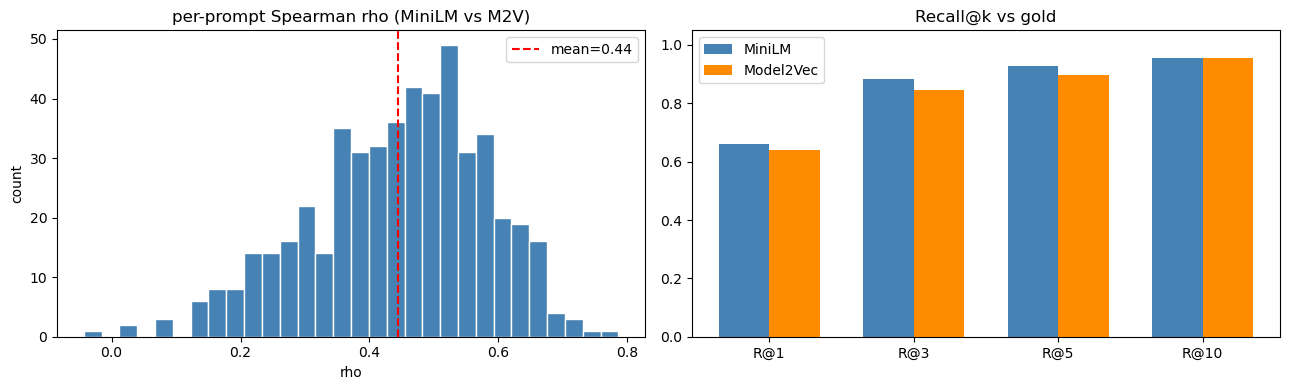

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(spearmans, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('per-prompt Spearman rho (MiniLM vs M2V)')
axes[0].set_xlabel('rho'); axes[0].set_ylabel('count')
axes[0].axvline(spearmans.mean(), color='red', linestyle='--', label=f'mean={spearmans.mean():.2f}')
axes[0].legend()

x = np.arange(len(Ks))
w = 0.35
rml = [recall_at_k(rank_ml, gold, k) for k in Ks]
rm2 = [recall_at_k(rank_m2, gold, k) for k in Ks]
axes[1].bar(x - w/2, rml, w, label='MiniLM', color='steelblue')
axes[1].bar(x + w/2, rm2, w, label='Model2Vec', color='darkorange')
axes[1].set_xticks(x); axes[1].set_xticklabels([f'R@{k}' for k in Ks])
axes[1].set_ylim(0, 1.05); axes[1].set_title('Recall@k vs gold')
axes[1].legend()
plt.tight_layout(); plt.show()

## Summary table

In [14]:
summary = {
    'MiniLM dim'              : coco_emb_ml.shape[1],
    'M2V dim'                 : coco_emb_m2.shape[1],
    'MobileCLIP2-B dim'       : coco_emb_mc.shape[1],
    'OpenCLIP-distill dim'    : coco_emb_ds.shape[1],
    'MiniLM ms/prompt'        : round(t_ml/len(prompts)*1000, 3),
    'M2V ms/prompt'           : round(t_m2/len(prompts)*1000, 3),
    'MobileCLIP2-B ms/prompt' : round(t_mc/len(prompts)*1000, 3),
    'OpenCLIP-distill ms/prompt': round(t_ds/len(prompts)*1000, 3),
    'MiniLM R@1'              : round(recall_at_k(rank_ml, gold, 1), 3),
    'M2V R@1'                 : round(recall_at_k(rank_m2, gold, 1), 3),
    'MobileCLIP2-B R@1'       : round(recall_at_k(rank_mc, gold, 1), 3),
    'OpenCLIP-distill R@1'    : round(recall_at_k(rank_ds, gold, 1), 3),
    'MiniLM R@5'              : round(recall_at_k(rank_ml, gold, 5), 3),
    'M2V R@5'                 : round(recall_at_k(rank_m2, gold, 5), 3),
    'MobileCLIP2-B R@5'       : round(recall_at_k(rank_mc, gold, 5), 3),
    'OpenCLIP-distill R@5'    : round(recall_at_k(rank_ds, gold, 5), 3),
    'MiniLM MRR'              : round(mrr(rank_ml, gold), 3),
    'M2V MRR'                 : round(mrr(rank_m2, gold), 3),
    'MobileCLIP2-B MRR'       : round(mrr(rank_mc, gold), 3),
    'OpenCLIP-distill MRR'    : round(mrr(rank_ds, gold), 3),
}
for k, v in summary.items():
    print(f'{k:30s} {v}')


MiniLM dim                     384
M2V dim                        256
MobileCLIP2-B dim              512
OpenCLIP-distill dim           256
MiniLM ms/prompt               0.23
M2V ms/prompt                  0.018
MobileCLIP2-B ms/prompt        3.742
OpenCLIP-distill ms/prompt     3.177
MiniLM R@1                     0.66
M2V R@1                        0.64
MobileCLIP2-B R@1              0.658
OpenCLIP-distill R@1           0.608
MiniLM R@5                     0.926
M2V R@5                        0.899
MobileCLIP2-B R@5              0.928
OpenCLIP-distill R@5           0.847
MiniLM MRR                     0.778
M2V MRR                        0.753
MobileCLIP2-B MRR              0.776
OpenCLIP-distill MRR           0.713


## Final comparison table (all 4 encoders)


## CPU latency pass (edge-equivalent)


In [15]:
# Build CPU clones of each encoder and time on the same 503 prompts.
import copy
from sentence_transformers import models  # noqa: F401  (ensures transformers cpu path is fine)

# --- MiniLM CPU ---
mini_model_cpu = AutoModel.from_pretrained(str(MINILM_PATH), local_files_only=True).cpu().eval()

@torch.no_grad()
def encode_minilm_cpu(texts):
    enc = mini_tok(list(texts), padding=True, truncation=True, return_tensors='pt')
    out = mini_model_cpu(**enc)
    v = _mean_pool(out.last_hidden_state, enc['attention_mask'])
    v = F.normalize(v, p=2, dim=-1)
    return v.numpy().astype(np.float32)

# --- Model2Vec already CPU ---  encode_m2v works as-is

# --- MobileCLIP2-B CPU ---
mc_ts_cpu = torch.jit.load(str(TS_PATH), map_location='cpu').eval()
_MC_FN_CPU = None
for n in ('encode_text','forward_text','text_features','forward'):
    if hasattr(mc_ts_cpu, n):
        _MC_FN_CPU = getattr(mc_ts_cpu, n); break

@torch.no_grad()
def encode_mobileclip_cpu(texts):
    ids = clip_tok(list(texts), padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt').input_ids
    out = _MC_FN_CPU(ids)
    out = out if isinstance(out, torch.Tensor) else out[0]
    if out.ndim > 2: out = out.mean(dim=1)
    v = F.normalize(out.float(), p=2, dim=-1)
    return v.numpy().astype(np.float32)

# --- OpenCLIP-Distilled MobileCLIP2-B CPU ---
ds_ts_cpu = torch.jit.load(str(TS_PATH), map_location='cpu').eval()
ds_ts_cpu.load_state_dict({k: v.cpu() for k, v in ckpt['student_state'].items()})
_DS_FN_CPU = None
for n in ('encode_text','forward_text','text_features','forward'):
    if hasattr(ds_ts_cpu, n):
        _DS_FN_CPU = getattr(ds_ts_cpu, n); break

ds_head_cpu = nn.Linear(student_dim, PROJ_DIM)
ds_head_cpu.load_state_dict({k: v.cpu() for k, v in ckpt['head_state'].items()})
ds_head_cpu.eval()

@torch.no_grad()
def encode_openclip_distill_cpu(texts):
    ids = clip_tok(list(texts), padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt').input_ids
    if L_CTX < ids.shape[1]:
        ids = ids.clone(); ids[:, L_CTX:] = 0
    out = _DS_FN_CPU(ids)
    out = out if isinstance(out, torch.Tensor) else out[0]
    if out.ndim > 2: out = out.mean(dim=1)
    v = ds_head_cpu(out.float())
    v = F.normalize(v, p=2, dim=-1)
    return v.numpy().astype(np.float32)


# Warm-ups
_ = encode_minilm_cpu(prompts[:4])
_ = encode_m2v(prompts[:4])
_ = encode_mobileclip_cpu(prompts[:4])
_ = encode_openclip_distill_cpu(prompts[:4])

# Timed
t0 = time.perf_counter(); _ = encode_minilm_cpu(prompts);            t_ml_cpu = time.perf_counter() - t0
t0 = time.perf_counter(); _ = encode_m2v(prompts);                   t_m2_cpu = time.perf_counter() - t0
t0 = time.perf_counter(); _ = encode_mobileclip_cpu(prompts);        t_mc_cpu = time.perf_counter() - t0
t0 = time.perf_counter(); _ = encode_openclip_distill_cpu(prompts);  t_ds_cpu = time.perf_counter() - t0

print(f'MiniLM            CPU: {t_ml_cpu/len(prompts)*1000:.2f} ms/prompt  (total {t_ml_cpu:.2f}s)')
print(f'Model2Vec         CPU: {t_m2_cpu/len(prompts)*1000:.3f} ms/prompt  (total {t_m2_cpu:.2f}s)')
print(f'MobileCLIP2-B     CPU: {t_mc_cpu/len(prompts)*1000:.2f} ms/prompt  (total {t_mc_cpu:.2f}s)')
print(f'OpenCLIP-distill  CPU: {t_ds_cpu/len(prompts)*1000:.2f} ms/prompt  (total {t_ds_cpu:.2f}s)')


C:\Users\Bimsara\AppData\Local\Temp\ipykernel_35788\3095054542.py:3: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers import models  # noqa: F401  (ensures transformers cpu path is fine)


MiniLM            CPU: 1.02 ms/prompt  (total 0.51s)
Model2Vec         CPU: 0.024 ms/prompt  (total 0.01s)
MobileCLIP2-B     CPU: 23.74 ms/prompt  (total 11.94s)
OpenCLIP-distill  CPU: 24.12 ms/prompt  (total 12.13s)


In [16]:
import os

SIZE_MB = {
    'MiniLM':                          90.0,
    'Model2Vec':                       8.0,
    'MobileCLIP2-B':                   os.path.getsize(TS_PATH) / 1e6,
    'OpenCLIP-Distilled MobileCLIP2-B': os.path.getsize(TS_PATH) / 1e6,
}

FPGA_FIT = {
    'MiniLM':                          'Poor  - attention + LayerNorm displace YOLO from BRAM',
    'Model2Vec':                       'Best  - static lookup + mean-pool, no attention',
    'MobileCLIP2-B':                   'Worst - full transformer; competes with YOLO for fabric',
    'OpenCLIP-Distilled MobileCLIP2-B': 'Poor  - same backbone as MobileCLIP2-B; head only saves 1 GEMV',
}

rows = [
    ('MiniLM',                           coco_emb_ml.shape[1],
     t_ml/len(prompts)*1000,    t_ml_cpu/len(prompts)*1000,
     recall_at_k(rank_ml, gold, 1), recall_at_k(rank_ml, gold, 5),
     recall_at_k(rank_ml, gold, 10), mrr(rank_ml, gold)),
    ('Model2Vec',                        coco_emb_m2.shape[1],
     t_m2/len(prompts)*1000,    t_m2_cpu/len(prompts)*1000,
     recall_at_k(rank_m2, gold, 1), recall_at_k(rank_m2, gold, 5),
     recall_at_k(rank_m2, gold, 10), mrr(rank_m2, gold)),
    ('MobileCLIP2-B',                    coco_emb_mc.shape[1],
     t_mc/len(prompts)*1000,    t_mc_cpu/len(prompts)*1000,
     recall_at_k(rank_mc, gold, 1), recall_at_k(rank_mc, gold, 5),
     recall_at_k(rank_mc, gold, 10), mrr(rank_mc, gold)),
    ('OpenCLIP-Distilled MobileCLIP2-B', coco_emb_ds.shape[1],
     t_ds/len(prompts)*1000,    t_ds_cpu/len(prompts)*1000,
     recall_at_k(rank_ds, gold, 1), recall_at_k(rank_ds, gold, 5),
     recall_at_k(rank_ds, gold, 10), mrr(rank_ds, gold)),
]

hdr = ['encoder', 'dim', 'GPU ms', 'CPU ms', 'R@1', 'R@5', 'R@10', 'MRR', 'size MB', 'FPGA fit']
widths = [34, 5, 8, 8, 7, 7, 7, 7, 9, 64]

def fmt(vals):
    return ' | '.join(str(v).ljust(w) for v, w in zip(vals, widths))

print(fmt(hdr))
print('-+-'.join('-' * w for w in widths))
for r in rows:
    name, dim, ms_g, ms_c, r1, r5, r10, m = r
    print(fmt([
        name, dim, f'{ms_g:.3f}', f'{ms_c:.3f}',
        f'{r1:.3f}', f'{r5:.3f}', f'{r10:.3f}', f'{m:.3f}',
        f'{SIZE_MB[name]:.1f}', FPGA_FIT[name],
    ]))

print()
print('### Markdown')
print()
print('| encoder | dim | GPU ms | CPU ms | R@1 | R@5 | R@10 | MRR | size MB | FPGA fit |')
print('|---|---|---|---|---|---|---|---|---|---|')
for r in rows:
    name, dim, ms_g, ms_c, r1, r5, r10, m = r
    print(f'| {name} | {dim} | {ms_g:.3f} | {ms_c:.3f} | {r1:.3f} | {r5:.3f} | {r10:.3f} | {m:.3f} | {SIZE_MB[name]:.1f} | {FPGA_FIT[name]} |')


encoder                            | dim   | GPU ms   | CPU ms   | R@1     | R@5     | R@10    | MRR     | size MB   | FPGA fit                                                        
-----------------------------------+-------+----------+----------+---------+---------+---------+---------+-----------+-----------------------------------------------------------------
MiniLM                             | 384   | 0.230    | 1.021    | 0.660   | 0.926   | 0.956   | 0.778   | 90.0      | Poor  - attention + LayerNorm displace YOLO from BRAM           
Model2Vec                          | 256   | 0.018    | 0.024    | 0.640   | 0.899   | 0.956   | 0.753   | 8.0       | Best  - static lookup + mean-pool, no attention                 
MobileCLIP2-B                      | 512   | 3.742    | 23.739   | 0.658   | 0.928   | 0.974   | 0.776   | 253.8     | Worst - full transformer; competes with YOLO for fabric         
OpenCLIP-Distilled MobileCLIP2-B   | 256   | 3.177    | 24.118   | 0.608   | 0.8